# 🚢 Titanic Survival Prediction

## 🌟 Project Overview

In this project, we built a **classification model** to predict whether a passenger on the Titanic survived or not.  
The goal was not only to train a machine learning model, but also to go through the **complete ML workflow** step by step: understanding the dataset, exploring it visually, preprocessing it, building multiple models, improving the features, and finally selecting the best-performing model.

This project is a great example of how data understanding and feature engineering can make a real difference in model performance.

---

## 🔍 Understanding the Dataset

We started by loading the dataset and exploring its overall structure.  
At this stage, we focused on:

- the number of rows and columns
- data types
- missing values
- the target variable distribution

One of the first important steps was analyzing the **`Survived`** column to understand how many passengers survived and how many did not.  
This helped us check whether the classes were balanced and gave us an early idea about the nature of the prediction problem.

---

## 📊 Exploratory Data Analysis (EDA)

Before jumping into modeling, we explored the data visually to better understand the factors that may have influenced survival.

We examined the relationship between survival and several important features, including:

- **Sex**
- **Passenger Class**
- **Age**
- **Fare**
- **Embarked Port**

These visualizations helped reveal meaningful patterns in the data.  
For example, some groups of passengers appeared to have a much higher chance of survival than others.  
This step gave us valuable intuition and helped guide the next stages of the project.

---

## 🏗️ Building the Baseline Models

After understanding the dataset, we selected a group of core features for the first version of the model:

- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`
- `Embarked`

We then split the dataset into:

- **Training data** for model learning
- **Validation data** for performance evaluation

To build a strong baseline, we trained and compared three different machine learning models:

- **Logistic Regression**
- **Random Forest**
- **XGBoost**

---

## ⚙️ Data Preprocessing

Before training the models, the data needed to be prepared properly.

The preprocessing steps included:

- handling missing values
- encoding categorical variables using **One-Hot Encoding**
- scaling numerical features for **Logistic Regression**

This stage was essential because machine learning models cannot work effectively with raw missing values or text-based categories.

---

## 🤔 Why Did We Improve the Model?

After training the initial models, the results were promising, but we noticed that there was still room for improvement.

Instead of looking only at **accuracy**, we also evaluated the models using:

- **Precision**
- **Recall**
- **F1-score**
- **Confusion Matrix**

This gave us a deeper understanding of model performance.  
We found that some models were better at predicting **non-survivors** than **survivors**, which meant that the model still needed improvement in identifying the passengers who actually survived.

That is why we moved to the next important step: **Feature Engineering**.

---

## 🧠 Feature Engineering

To improve the models, we created new features that could better represent each passenger’s situation.

### 1. FamilySize
This feature represents the total family size traveling with the passenger:

`FamilySize = SibSp + Parch + 1`

### 2. IsAlone
This feature indicates whether the passenger was traveling alone or not.

### 3. Title
We extracted the passenger’s title from the **Name** column, such as:

- Mr
- Mrs
- Miss
- Master

This feature was especially useful because it can reflect information related to **gender**, **age group**, and sometimes even **social status**.

---

## 💡 Why Were These Features Helpful?

These engineered features added more meaning to the dataset.

For example:

- traveling with family may influence survival chances
- traveling alone may reflect a different survival pattern
- titles can help distinguish between men, women, and children

In other words, feature engineering helped the models capture patterns that were not directly obvious from the original columns alone.

This is one of the most exciting parts of machine learning: sometimes the real improvement comes not from changing the model, but from **improving the way the data is represented**.

---

## 📈 Model Improvement and Results

After adding the new features, we updated the feature set, preprocessed the data again, and retrained the three models.

This time, the results became more meaningful and better balanced.

Among all models, **Logistic Regression** achieved the best overall performance on the validation set.

It provided:

- the **highest accuracy**
- better **recall** for the survived class
- a more balanced **F1-score**

This was an important outcome because our goal was not just to maximize accuracy, but to build a model that could better identify the passengers who actually survived.

---

## ✅ Why Logistic Regression Was the Best Choice

Although **Random Forest** and **XGBoost** are powerful models, **Logistic Regression** performed the best in this project.

It offered a strong balance between:

- overall accuracy
- ability to detect survivors
- simplicity
- interpretability

This result is a great reminder that a simpler model can sometimes outperform more complex ones when the features are well chosen and the data is prepared carefully.

---

## 🏁 Conclusion

In this project, we followed the essential steps of a complete machine learning pipeline:

1. understanding the dataset  
2. exploring the data visually  
3. cleaning and preprocessing the data  
4. building multiple baseline models  
5. evaluating the results using different metrics  
6. improving the dataset through feature engineering  
7. retraining the models  
8. selecting the best-performing model  

Overall, this project showed that **good data understanding** and **thoughtful feature engineering** can significantly improve model performance.

It also demonstrated that choosing the best model should never depend on accuracy alone.  
A strong model is one that performs well across multiple evaluation metrics and gives reliable predictions for the class that matters most.

---

## ❤️ Final Note

This project was more than just predicting survival on the Titanic.  
It was a practical journey through the mindset of machine learning:  
**understand the data, question the results, improve the features, and let the model learn from a better story.**

In [1]:
# Step 1: Import Libraries and Load the Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("Titanic-Dataset.csv")
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Step 2: Understand the Dataset

print("Shape of dataset:", train_df.shape)
print("\nColumns:\n", train_df.columns.tolist())
print("\nInfo:")
train_df.info()

Shape of dataset: (891, 12)

Columns:
 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
print("\nMissing values:")
print(train_df.isnull().sum())


Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
train_df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [5]:
# Step 3: Check Target Variable Distribution

train_df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

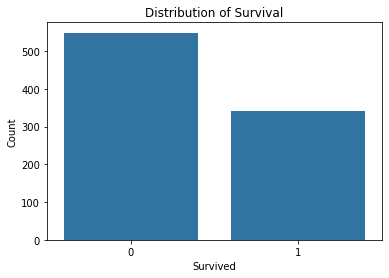

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Survived")
plt.title("Distribution of Survival")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

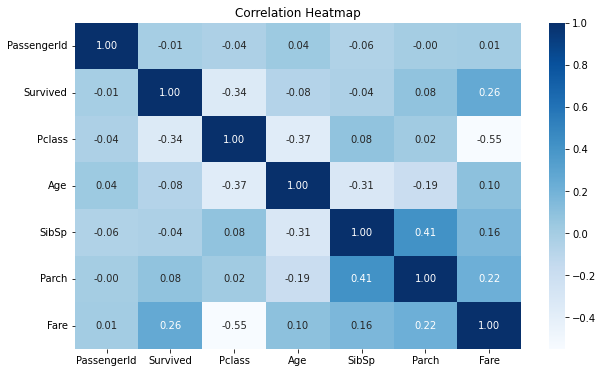

In [8]:
# Step 4: Correlation Heatmap

plt.figure(figsize=(10,6))
numeric_df = train_df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

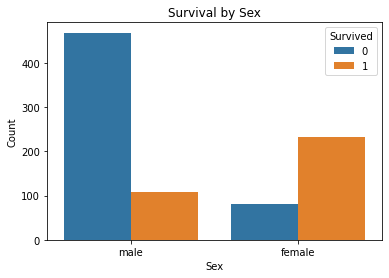

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

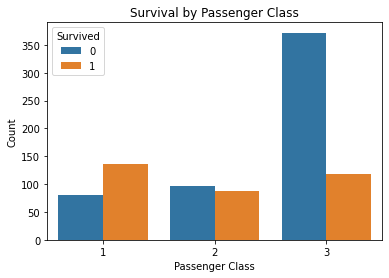

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

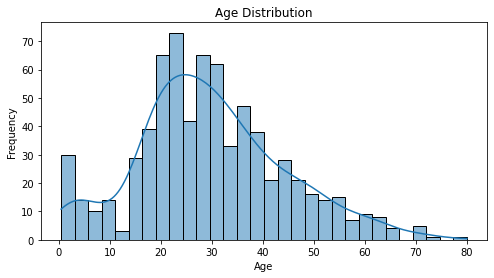

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(train_df["Age"].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

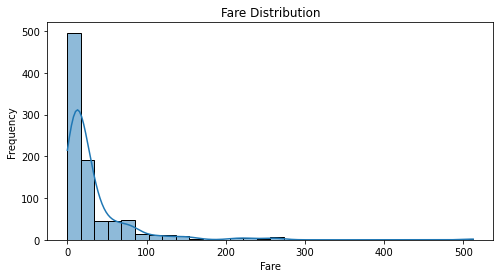

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(train_df["Fare"].dropna(), bins=30, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

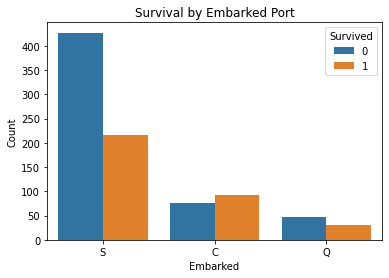

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Embarked", hue="Survived")
plt.title("Survival by Embarked Port")
plt.xlabel("Embarked")
plt.ylabel("Count")
plt.show()

In [14]:
# Step 5: Select Features and Target

features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target = "Survived"

X = train_df[features]
y = train_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 7)
y shape: (891,)


In [16]:
# Step 6: Split the Data into Training and Validation Sets

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (712, 7)
X_valid shape: (179, 7)
y_train shape: (712,)
y_valid shape: (179,)


In [18]:
# Step 7: Build the Models

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [19]:
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Sex", "Embarked"]

numeric_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lr, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [20]:
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_lr),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            min_samples_split=5,
            random_state=42
        ))
    ]),
    
    "XGBoost": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", XGBClassifier(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42
        ))
    ])
}

In [21]:
# Step 8: Train and Evaluate the Models

results = []
predictions = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_valid)
    acc = accuracy_score(y_valid, y_pred)

    print("\n" + "="*50)
    print(name)
    print("="*50)
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_valid, y_pred))

    results.append((name, acc))
    predictions[name] = y_pred


Logistic Regression
Accuracy: 0.8045
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179


Random Forest
Accuracy: 0.8101
              precision    recall  f1-score   support

           0       0.79      0.95      0.86       110
           1       0.87      0.59      0.71        69

    accuracy                           0.81       179
   macro avg       0.83      0.77      0.78       179
weighted avg       0.82      0.81      0.80       179


XGBoost
Accuracy: 0.7933
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       110
           1       0.78      0.65      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.7

In [22]:
# Step 9: Compare Model Performance

results_df = pd.DataFrame(results, columns=["Model", "Validation Accuracy"])
results_df = results_df.sort_values(by="Validation Accuracy", ascending=False)
results_df

,Model,Validation Accuracy
1,Random Forest,0.810056
0,Logistic Regression,0.804469
2,XGBoost,0.793296


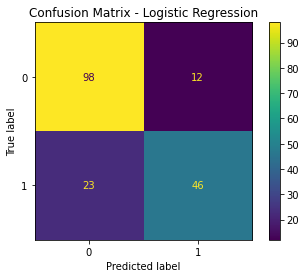

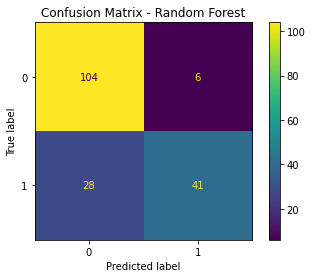

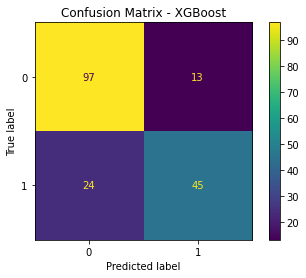

In [23]:
# Step 10: Display the Confusion Matrix for Each Model

for name in predictions:
    ConfusionMatrixDisplay.from_predictions(y_valid, predictions[name])
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [24]:
# Step 11: Select the Best Model

best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Random Forest


In [25]:
# Step 12: Train the Best Model on the Full Dataset

best_model = models[best_model_name]
best_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model',
                 RandomForestClassifier(max_depth=5, min_samples_split=5,
                                        n_estimators=300, random_state=42))])

In [26]:
# Step: Feature Engineering

train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1
train_df["IsAlone"] = (train_df["FamilySize"] == 1).astype(int)
train_df["Title"] = train_df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

train_df["Title"] = train_df["Title"].replace(
    ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"],
    "Rare"
)
train_df["Title"] = train_df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

In [27]:
# Step: Update Features and Target

features = [
    "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked",
    "FamilySize", "IsAlone", "Title"
]
target = "Survived"

X = train_df[features]
y = train_df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())

X shape: (891, 10)
y shape: (891,)
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked  FamilySize  IsAlone  \
0       3    male  22.0      1      0   7.2500        S           2        0   
1       1  female  38.0      1      0  71.2833        C           2        0   
2       3  female  26.0      0      0   7.9250        S           1        1   
3       1  female  35.0      1      0  53.1000        S           2        0   
4       3    male  35.0      0      0   8.0500        S           1        1   

  Title  
0    Mr  
1   Mrs  
2  Miss  
3   Mrs  
4    Mr  


In [28]:
# Step: Split the Data

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (712, 10)
X_valid shape: (179, 10)
y_train shape: (712,)
y_valid shape: (179,)


In [29]:
# Step: Define Numeric and Categorical Features

numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone"]
categorical_features = ["Sex", "Embarked", "Title"]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
Categorical features: ['Sex', 'Embarked', 'Title']


In [30]:
# Step: Import Preprocessing Tools

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [31]:
# Step: Build Preprocessors

numeric_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [32]:
numeric_transformer_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

In [33]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [35]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lr, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessors created successfully.")

Preprocessors created successfully.


In [37]:
# Step: Build the Improved Models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor_lr),
        ("model", LogisticRegression(
            max_iter=2000,
            C=0.5,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=6,
            min_samples_split=4,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("model", XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42
        ))
    ])
}

print(models.keys())

dict_keys(['Logistic Regression', 'Random Forest', 'XGBoost'])


In [38]:
# Step: Import Evaluation Tools

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

In [39]:
# Step: Train and Evaluate the Models

results = []
predictions = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_valid)

    acc = accuracy_score(y_valid, y_pred)

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_valid, y_pred))

    results.append((name, acc))
    predictions[name] = y_pred


Logistic Regression
Accuracy: 0.8324
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       110
           1       0.77      0.81      0.79        69

    accuracy                           0.83       179
   macro avg       0.82      0.83      0.82       179
weighted avg       0.83      0.83      0.83       179


Random Forest
Accuracy: 0.8268
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       110
           1       0.78      0.77      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179


XGBoost
Accuracy: 0.8156
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.8

In [40]:
# Step: Compare Results in a Table

results_df = pd.DataFrame(results, columns=["Model", "Validation Accuracy"])
results_df = results_df.sort_values(by="Validation Accuracy", ascending=False)

results_df

,Model,Validation Accuracy
0,Logistic Regression,0.832402
1,Random Forest,0.826816
2,XGBoost,0.815642


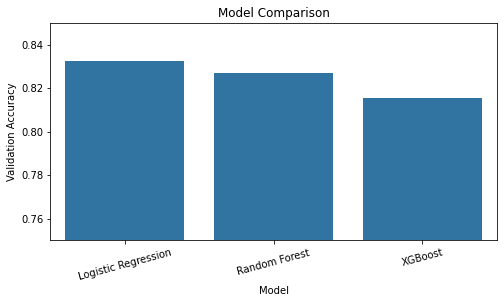

In [41]:
# Step: Plot Model Comparison
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Model", y="Validation Accuracy")
plt.title("Model Comparison")
plt.ylim(0.75, 0.85)
plt.xticks(rotation=15)
plt.show()

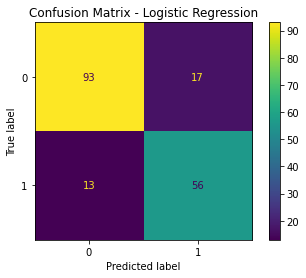

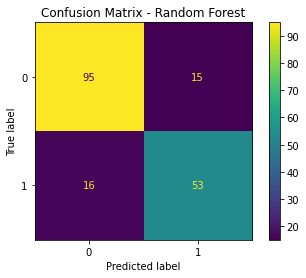

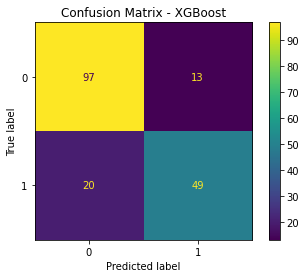

In [42]:
# Step: Plot Confusion Matrix for Each Model

from sklearn.metrics import ConfusionMatrixDisplay

for name in predictions:
    ConfusionMatrixDisplay.from_predictions(y_valid, predictions[name])
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [43]:
# Step: Select the Best Model

best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [44]:
# Step: Train the Best Model on the Full Dataset

best_model = models[best_model_name]
best_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize', 'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'Title'])])),
                ('model',
                 LogisticRegression(C=0.5, class_weight='balanced',
                                    max_iter=2000, random_state=42))])

In [48]:
# Step: Save the Best Model
import pickle

filename = "best_titanic_model.pkl"
pickle.dump(best_model, open(filename, 'wb'))
print("Best model saved successfully.")




Best model saved successfully.
